## Les inégalités de revenu varient elles selon le sexe, l'origine et le statut marital ? 

## ⚙️ Indice de Gini, algo de calcul


### 1-Librairies et dataset

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("Data/adult_S12.csv")
data = data.replace("?", np.nan).dropna()

# Encodage du revenu en numérique
data['income_num'] = data['income'].map({'>50K': 1, '<=50K': 0})

### 2-Indice de Gini

In [4]:
def gini(array):
    array = np.sort(array)
    n = len(array)
    cumulative = np.cumsum(array)
    return (n + 1 - 2 * np.sum(cumulative) / cumulative[-1]) / n

In [ ]:
# Gini par sexe, origine et statut marital

gini_gender = data.groupby('gender')['income_num'].apply(gini)
gini_race = data.groupby('race')['income_num'].apply(gini)
gini_marital = data.groupby('marital-status')['income_num'].apply(gini)

print("Gini par sexe:\n", gini_gender)
print("\nGini par origine:\n", gini_race)
print("\nGini par statut marital:\n", gini_marital)

Gini par sexe:
 gender
Female    0.886424
Male      0.687523
Name: income_num, dtype: float64

Gini par origine:
 race
Amer-Indian-Eskimo    0.878161
Asian-Pac-Islander    0.716807
Black                 0.873699
Other                 0.872521
White                 0.737629
Name: income_num, dtype: float64

Gini par statut marital:
 marital-status
Divorced                 0.895982
Married-AF-spouse        0.562500
Married-civ-spouse       0.545761
Married-spouse-absent    0.902174
Never-married            0.951980
Separated                0.929837
Widowed                  0.905247
Name: income_num, dtype: float64


### 3-Visualisation

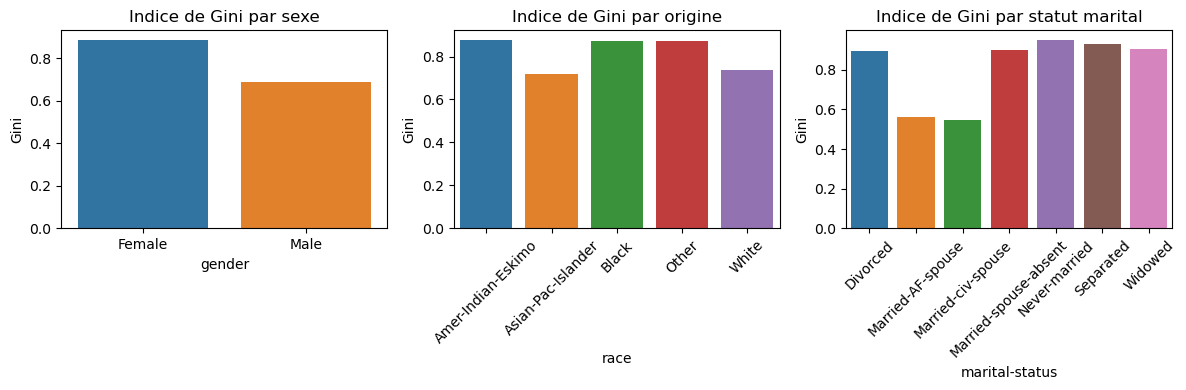

In [7]:
plt.figure(figsize=(12,4))

# Sexe
plt.subplot(1,3,1)
sns.barplot(x=gini_gender.index, y=gini_gender.values)
plt.title("Indice de Gini par sexe")
plt.ylabel("Gini")

# Origine
plt.subplot(1,3,2)
sns.barplot(x=gini_race.index, y=gini_race.values)
plt.title("Indice de Gini par origine")
plt.ylabel("Gini")
plt.xticks(rotation=45)

# Statut marital
plt.subplot(1,3,3)
sns.barplot(x=gini_marital.index, y=gini_marital.values)
plt.title("Indice de Gini par statut marital")
plt.ylabel("Gini")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### 4-Résumé

Les résultats montrent que les inégalités de revenu varient fortement selon le sexe, l’origine et le statut marital. Le Gini est plus élevé chez les femmes, ce qui indique une distribution de revenu plus inégale que chez les hommes. Les inégalités sont également marquées dans plusieurs groupes d’origine, notamment chez les populations amérindiennes, noires et “other”, où le Gini dépasse 0,87. 
Enfin, le statut marital apparaît comme un facteur déterminant : les personnes jamais mariées, séparées ou veuves présentent les niveaux d’inégalité les plus élevés, tandis que les couples mariés affichent une distribution de revenu plus homogène.
Globalement, ces résultats confirment que les inégalités salariales ne sont pas uniformes et qu’elles dépendent fortement de caractéristiques socio‑démographiques structurantes.